In [1]:
import requests
from datetime import datetime
import pandas as pd 
import numpy as np

## **I. API Request**

In [117]:
class FlightDataCollector:
    def __init__(self, api_key):
        self.api_key = api_key
        self.base_url = "http://api.aviationstack.com/v1/flights"

    def get_time_category(self, dt_str):
        """Transforme une date ISO en catégorie (Morning, Afternoon, etc.)"""
        dt = datetime.fromisoformat(dt_str.replace('Z', '+00:00'))
        hour = dt.hour
        
        if 5 <= hour < 12:
            return "Morning"
        elif 12 <= hour < 17:
            return "Afternoon"
        elif 17 <= hour < 21:
            return "Evening"
        else:
            return "Night"

    def calculate_duration(self, dep_str, arr_str):
        """Calcule la durée du vol en heures décimales"""
        dep = datetime.fromisoformat(dep_str.replace('Z', '+00:00'))
        arr = datetime.fromisoformat(arr_str.replace('Z', '+00:00'))
        duration = arr - dep
        return round(duration.total_seconds() / 3600, 2)

    def fetch_and_format(self, origin, destination, ticket_class="Economy"):
        """Récupère les données et les formate pour le modèle Kaggle"""
        params = {
            'access_key': self.api_key,
            'dep_iata': origin,
            'arr_iata': destination,
            'limit': 3,
        }

        try:
            response = requests.get(self.base_url, params=params)
            response.raise_for_status()
            res_json = response.json()
            
            if not res_json.get('data'):
                return {"error": "Aucun vol trouvé pour ce trajet aujourd'hui."}

            flight_raw = res_json['data'][0]


            formatted_data = {
                "airline": flight_raw['airline']['name'],
                "flight": flight_raw['flight']['iata'],
                "source_city": flight_raw['departure']['airport'],
                "departure_time": self.get_time_category(flight_raw['departure']['scheduled']),
                "stops": "zero", 
                "arrival_time": self.get_time_category(flight_raw['arrival']['scheduled']),
                "destination_city": flight_raw['arrival']['airport'],
                "class": ticket_class,
                "duration": self.calculate_duration(
                    flight_raw['departure']['scheduled'], 
                    flight_raw['arrival']['scheduled']
                )
            }
            return formatted_data

        except Exception as e:
            return {"error": f"Erreur de connexion à l'API: {str(e)}"}


In [ ]:
if __name__ == "__main__":
    
    API_KEY = "a437ae3887c78bd01e39487b455ef8c1" 
    collector = FlightDataCollector(API_KEY)
    result = collector.fetch_and_format("CDG", "DEL", ticket_class="Economy")
    print(result)

Données prêtes pour le modèle ML :
{'airline': 'Air India', 'flight': 'AI148', 'source_city': 'Charles De Gaulle', 'departure_time': 'Afternoon', 'stops': 'zero', 'arrival_time': 'Night', 'destination_city': 'Indira Gandhi International', 'class': 'Economy', 'duration': 13.17}


## **II.Data analysis**

In [2]:
df_raw = pd.read_csv("/home/perann/Bureau/ENSAE/3A/mise en prod/MEP/data/plane_tickets/airlines_flights_data.csv", index_col= 0)


def tweak_data(df : pd.DataFrame)-> pd.DataFrame:
    return (df.drop(columns = "flight")
            .astype({'class' : 'category', 
                    'stops' : 'category',
                    'airline' : 'category'}))

df = tweak_data(df_raw)

In [3]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099


/tmp/ipykernel_71188/2801413559.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[["airline", 'price']].groupby('airline').agg(['mean']).plot.bar()


<Axes: xlabel='airline'>

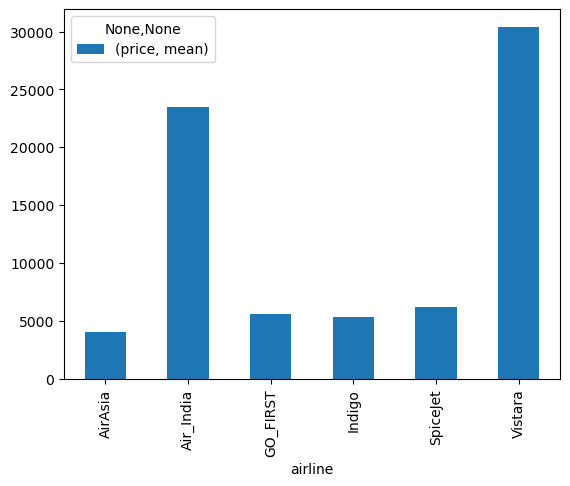

In [6]:
df[["airline", 'price']].groupby('airline').agg(['mean']).plot.bar()

<Axes: xlabel='departure_time'>

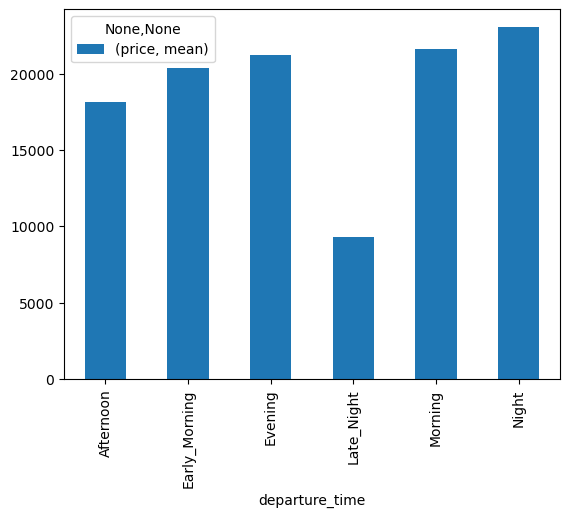

In [7]:
df[["departure_time", "price"]].groupby('departure_time').agg(['mean']).plot.bar()

## **III. Price predictor**

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

cat_columns = ["airline", "source_city", "departure_time", "stops", "arrival_time", "destination_city", "class"]
num_columns = ["duration", "days_left", "price"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False), cat_columns),
        ("num", MinMaxScaler(), num_columns)
    ],
    
    remainder="passthrough")

processed_data = preprocessor.fit_transform(df)
features_names = preprocessor.get_feature_names_out()
df_model = pd.DataFrame(processed_data, columns=features_names)



In [12]:
X_train, X_test = train_test_split(df_model, test_size= 0.2)

y_train = X_train[["num__price"]].values
X_train = X_train.drop(columns = "num__price").values

y_test = X_test[["num__price"]].values
X_test = X_test.drop(columns = "num__price").values


from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 5, 10]
}


grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print(grid.best_params_)


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators= 100, learning_rate = 0.1)

model.fit(X_train, y_train)


/home/perann/Bureau/ENSAE/3A/mise en prod/MEP/.pixi/envs/default/lib/python3.10/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [20]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test)

root_mean_squared_error(y_test,y_pred), mean_absolute_error(y_test, y_pred)

(0.04063384209392154, 0.024165864649755984)

## **IV. MLFlow uploading**

In [27]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import cross_val_score
from mlflow.models.signature import infer_signature

In [34]:
mlflow.set_experiment("project")

with mlflow.start_run():

    params = {"n_estimators": 100, "learning_rate": 0.01}
    mlflow.log_params(params)
    
   
    model = GradientBoostingRegressor(**params)
    

    scores = cross_val_score(model, X_train, y_train, cv=5)
    mean_accuracy = scores.mean()
    
    
    mlflow.log_metric("mean_accuracy", mean_accuracy)
    

    model.fit(X_train, y_train)
    
    signature = infer_signature(X_train, model.predict(X_train))

    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
        signature=signature,
        input_example=X_train[:5] 
    )
    
    print(f"Model registered,  accuracy : {mean_accuracy}")


/home/perann/Bureau/ENSAE/3A/mise en prod/MEP/.pixi/envs/default/lib/python3.10/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/home/perann/Bureau/ENSAE/3A/mise en prod/MEP/.pixi/envs/default/lib/python3.10/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/home/perann/Bureau/ENSAE/3A/mise en prod/MEP/.pixi/envs/default/lib/python3.10/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True

Model registered,  accuracy : 0.8102877492660537
